
# Deepfake Detection Project Walkthrough

This notebook walks through the parts of our deepfake detection course project that matter for reproducing our final results. It keeps the workflow self-contained so we can rerun the experiments without editing the main toolkit source code. 

The classification section trains a compact model that labels SID_Set frames as real, synthetic, or tampered, while the segmentation section trains a U-Net style network that highlights manipulated regions. Along the way we point out how to configure the runs, how the data is preprocessed, and where artefacts are saved so you can repeat the experiments or adapt them to different datasets.


## Quick-start Guide

Create a clean Python 3.10 or newer environment before you open this notebook. On macOS or Linux you can run `python3 -m venv .venv` followed by `source .venv/bin/activate`, and on Windows you can activate with `.venv\Scripts\activate`. Conda works as well as long as it targets the same Python version.

Install the required packages from your terminal or by running the optional installation cell below, then launch Jupyter Notebook or JupyterLab from the activated environment and open this file. Work through the cells from top to bottom, and stop after the classification section if you do not need the segmentation walkthrough.

In [1]:

# This optional cell installs the exact package versions used during development so the notebook behaves consistently across machines.
# Run it only if you prefer managing dependencies from inside the notebook rather than a terminal session.
# The first command upgrades pip to avoid resolver issues, and the second command installs the libraries required for both the classification and segmentation workflows.
%pip install --upgrade pip
%pip install torch==2.8.0 torchvision==0.23.0 datasets scikit-learn matplotlib seaborn pillow tqdm optuna

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



### Verify the runtime

Run the next cell to confirm the Python and PyTorch versions that your environment is using and to check whether CUDA hardware is available. Knowing this up front helps set expectations for training speed and avoids confusion when the GPU path is not accessible.



In [2]:

# Verifying the runtime helps confirm that the environment matches the versions we tested and reveals whether CUDA acceleration is available.
# The printed summary includes the Python interpreter, the PyTorch build, and the detected GPU name when one is present.
import platform
import torch

print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device    : {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("Running on CPU. Expect training to take a few extra minutes.")



Python version : 3.13.7
PyTorch version: 2.8.0+cu128
CUDA available : True
GPU device    : NVIDIA GeForce RTX 5060 Ti


## Part A — Classification Pipeline

This portion reorganises the classification workflow into clearly defined sections.

### A.1 Initialization Section — Imports And Reproducibility Helpers

We begin by assembling every external dependency and providing utility helpers that enforce deterministic behaviour. Explaining the reasoning here prevents confusion later when repeated runs produce matching results or when CUDA is not available on a workstation.


In [3]:
# ==================================================================================================
# Initialization Section — Imports And Reproducibility Helpers
# ==================================================================================================
# The imports collect the scientific Python stack required for classification. PyTorch supplies tensor
# operations and neural network components, torchvision covers augmentation utilities, Hugging Face
# Datasets streams SID_Set frames, and matplotlib plus seaborn assist in lightweight diagnostics.
# Keeping imports grouped clarifies the external requirements before any computation begins.
import json
import math
import random
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch import amp
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2 as T
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix


def cls_set_seed(seed: int) -> None:
    """
    Reseed every pseudo-random number generator that influences the training process so repeated runs
    stay comparable. cudnn.benchmark is disabled because adaptive kernel selection introduces
    non-determinism even when other seeds match.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def cls_timestamp() -> str:
    """
    Produce a UTC timestamp used for naming artefacts. UTC avoids daylight saving shifts and keeps
    folders lexicographically ordered when browsing historical experiments.
    """
    return datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


def cls_device() -> torch.device:
    """
    Select the most capable execution device. CUDA is preferred when available, otherwise the CPU
    path is taken. Centralising the logic keeps downstream code simple.
    """
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/home/kevin/miniconda3/envs/deepfake-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### A.2 Configuration Section — Experiment Hyperparameters And Run Directory

Next we gather every tunable value inside a single configuration dictionary, establish the run folder, and seed the random number generators. Documenting the rationale for these defaults makes it easier to tweak them deliberately rather than by trial-and-error.


In [4]:
# ==================================================================================================
# Configuration Section — Experiment Hyperparameters And Run Directory
# ==================================================================================================
# The configuration keeps the demonstration compact while exercising the entire workflow. Dataset
# slices remain small enough for quick feedback, the learning rate pairs well with AdamW under cosine
# decay, and the epoch count highlights convergence without overfitting the limited sample.
CLASS_CFG = {
    'dataset_name': 'saberzl/SID_Set',
    'image_size': 128,
    'train_samples': 160,
    'val_samples': 64,
    'test_samples': 64,
    'batch_size': 16,
    'num_workers': 0,
    'learning_rate': 1e-3,
    'epochs': 15,
    'label_smoothing': 0.05,
    'grad_clip_norm': 2.0,
    'ema_decay': 0.995,
    'use_cosine_schedule': True,
    'augment': True,
    'random_erasing_prob': 0.25,
    'seed': 42,
    'output_root': Path('project_outputs_classification'),
}

# Determinism comes first so an identical configuration yields identical behaviour across machines.
CLASS_CFG['output_root'].mkdir(parents=True, exist_ok=True)
cls_set_seed(CLASS_CFG['seed'])

# Capturing device information and timestamps up front embeds provenance in every artefact name.
CLASS_DEVICE = cls_device()
CLASS_RUN_ID = cls_timestamp()
CLASS_RUN_DIR = CLASS_CFG['output_root'] / CLASS_RUN_ID
CLASS_RUN_DIR.mkdir(parents=True, exist_ok=True)

print('Classification configuration:')
print(json.dumps({k: (str(v) if isinstance(v, Path) else v) for k, v in CLASS_CFG.items()}, indent=2))
print('Device:', CLASS_DEVICE)
print('Output folder:', CLASS_RUN_DIR)


Classification configuration:
{
  "dataset_name": "saberzl/SID_Set",
  "image_size": 128,
  "train_samples": 160,
  "val_samples": 64,
  "test_samples": 64,
  "batch_size": 16,
  "num_workers": 0,
  "learning_rate": 0.001,
  "epochs": 15,
  "label_smoothing": 0.05,
  "grad_clip_norm": 2.0,
  "ema_decay": 0.995,
  "use_cosine_schedule": true,
  "augment": true,
  "random_erasing_prob": 0.25,
  "seed": 42,
  "output_root": "project_outputs_classification"
}
Device: cuda
Output folder: project_outputs_classification/20251102T134048Z


/tmp/ipykernel_79167/4072564302.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


### A.3 Data Preparation Section — Transforms, Dataset Wrappers, And Loaders

The next block details how frames are transformed, wrapped, and streamed into the model. Emphasising why augmentations are chosen and how datasets are sliced clarifies the relationship between configuration values and the samples that reach the optimiser.


In [5]:
# ==================================================================================================
# Data Preparation Section — Transforms, Dataset Wrappers, And Loaders
# ==================================================================================================
# SID_Set arrives as PIL imagery paired with integer labels. We convert those assets into PyTorch
# tensors, apply carefully chosen augmentations, and expose deterministic DataLoaders for training,
# validation, and testing so later stages can remain concise.
CLASS_NAMES = ['Real', 'Synthetic', 'Tampered']


def class_transforms(image_size: int, augment: bool, random_erasing_prob: float) -> T.Compose:
    """
    Build the transformation pipeline applied to each frame.

    The image_size argument fixes the spatial resolution expected by the classifier. Passing augment
    as True introduces geometric and colour perturbations so the model encounters diverse appearances
    during training, while evaluation runs keep augment False for stability. random_erasing_prob
    controls how often a small patch is removed, nudging the classifier toward distributed evidence
    rather than memorising a single region.
    """
    ops = []

    if augment:
        ops.append(T.RandomResizedCrop(image_size, scale=(0.6, 1.0), ratio=(0.75, 1.33)))
        ops.append(T.RandomHorizontalFlip(p=0.5))
        ops.append(T.RandomApply([T.RandomPerspective(distortion_scale=0.08)], p=0.3))
        ops.append(T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.04))
        ops.append(T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3))
    else:
        ops.append(T.Resize((image_size, image_size), antialias=True))

    ops.extend([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    if augment and random_erasing_prob > 0:
        ops.append(T.RandomErasing(p=random_erasing_prob, scale=(0.02, 0.2), ratio=(0.3, 3.3)))

    return T.Compose(ops)


class ClassificationDataset(Dataset):
    """
    Wrap a Hugging Face split so each item returns a normalised tensor image and its categorical label.

    Returning dictionaries keeps the downstream training loop self-documenting because keys signal
    which tensors are present in each batch.
    """

    def __init__(self, hf_dataset, image_size: int, augment: bool, random_erasing_prob: float):
        self.dataset = hf_dataset
        self.transform = class_transforms(image_size, augment, random_erasing_prob)

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        record = self.dataset[idx]
        image = record['image'].convert('RGB')
        tensor = self.transform(image)
        label = torch.tensor(int(record['label']), dtype=torch.long)
        return {'image': tensor, 'label': label}


def build_class_loaders(cfg: dict) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Create deterministic train, validation, and test DataLoaders that honour the configuration.

    Hugging Face slicing notation fixes the sample identities, ensuring repeated notebook executions
    operate on the same frames. Validation and test loaders disable augmentation to reveal true
    generalisation characteristics.
    """
    hf_train = load_dataset(cfg['dataset_name'], split=f"train[:{cfg['train_samples']}]")
    hf_val = load_dataset(cfg['dataset_name'], split=f"validation[:{cfg['val_samples']}]")
    hf_test = load_dataset(
        cfg['dataset_name'],
        split=f"validation[{cfg['val_samples']}:{cfg['val_samples'] + cfg['test_samples']}]",
    )

    train_ds = ClassificationDataset(
        hf_train,
        cfg['image_size'],
        augment=cfg['augment'],
        random_erasing_prob=cfg['random_erasing_prob'],
    )
    val_ds = ClassificationDataset(
        hf_val,
        cfg['image_size'],
        augment=False,
        random_erasing_prob=0.0,
    )
    test_ds = ClassificationDataset(
        hf_test,
        cfg['image_size'],
        augment=False,
        random_erasing_prob=0.0,
    )

    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=cfg['num_workers'])
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=cfg['num_workers'])
    test_loader = DataLoader(test_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=cfg['num_workers'])

    return train_loader, val_loader, test_loader


train_loader_c, val_loader_c, test_loader_c = build_class_loaders(CLASS_CFG)
print('Classification dataloaders -> train:', len(train_loader_c), 'val:', len(val_loader_c), 'test:', len(test_loader_c))


Classification dataloaders -> train: 10 val: 4 test: 4


### A.4 Visual Inspection Section — Sanity Checking Augmentation

Before spending time on optimisation we visually audit a batch of transformed images. This ensures the augmentation recipe genuinely represents plausible footage and surfaces any accidental colour or geometric artefacts.


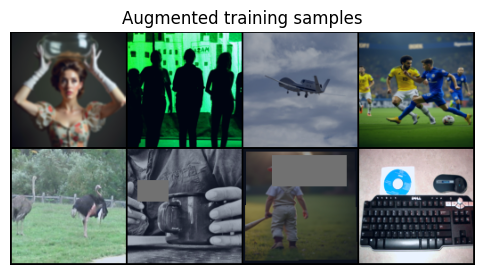

In [6]:
# ==================================================================================================
# Visual Inspection Section — Sanity Checking Augmentation
# ==================================================================================================
# Sampling a batch and plotting it provides immediate feedback on whether transformations behave as
# designed. Unexpected colour shifts or overly aggressive warps are easier to catch visually than by
# reading configuration dictionaries.
batch_preview = next(iter(train_loader_c))
grid = vutils.make_grid(batch_preview['image'][:8], nrow=4, normalize=True)
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
plt.title('Augmented training samples')
plt.axis('off')
plt.show()


### A.5 Model Definition Section — Compact Convolutional Architecture

With data flowing, we describe the classifier architecture and justify the design choices. Highlighting how each block functions helps a future maintainer decide when to scale capacity or swap layers.


In [7]:
# ==================================================================================================
# Model Definition Section — Compact Convolutional Architecture
# ==================================================================================================
# The network stays deliberately lightweight so it trains quickly even on modest GPUs. A shallow stem
# followed by progressively wider stages captures local textures while keeping parameter counts small.
# Dropout in the head mitigates overfitting on the limited dataset slice.
class Classifier(nn.Module):
    """
    Three-class convolutional network tailored to the SID_Set taxonomy.

    The base_width argument sets the channel count for the initial stage and scales the subsequent
    stages proportionally. Increasing it is a straightforward way to add representational capacity
    if the dataset expands. The num_classes argument maps directly to the Real, Synthetic, Tampered
    labels used throughout the project.
    """

    def __init__(self, base_width: int = 32, num_classes: int = 3):
        super().__init__()
        widths = [base_width, base_width * 2, base_width * 4]

        self.stem = self._block(3, widths[0])
        self.stage1 = self._block(widths[0], widths[1])
        self.stage2 = self._block(widths[1], widths[2])
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(widths[2], widths[2]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(widths[2], num_classes),
        )

    @staticmethod
    def _block(in_ch: int, out_ch: int) -> nn.Sequential:
        """
        Assemble a residual-style pair of convolutions with batch normalisation and ReLU activations.

        Two convolutions with shared channel counts balance receptive field growth and compute cost.
        BatchNorm stabilises gradients, and in-place ReLU conserves memory during backpropagation.
        """
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply the convolutional stages followed by global pooling and the fully connected head.

        The input tensor has shape batch by channels by height by width. The returned tensor contains
        raw logits; softmax is deferred to the loss function for numerical stability.
        """
        x = self.pool(self.stem(x))
        x = self.pool(self.stage1(x))
        x = self.stage2(x)
        return self.head(x)


### A.6 Optimisation Setup Section — Loss Function, Optimiser, And Scheduler

We now orchestrate the components that govern how the network learns. Providing context around label smoothing, the optimiser choice, and the exponential moving average explains why the training loop later on uses these particular ingredients.


In [8]:
# ==================================================================================================
# Optimisation Setup Section — Loss Function, Optimiser, And Scheduler
# ==================================================================================================
# Cross-entropy with label smoothing guards against overconfidence on a compact dataset, AdamW offers
# robust updates with decoupled weight decay, and an exponential moving average (EMA) snapshot tends to
# evaluate more smoothly than the raw weights when the dataset is small.
model_c = Classifier(num_classes=len(CLASS_NAMES)).to(CLASS_DEVICE)
criterion_c = nn.CrossEntropyLoss(label_smoothing=CLASS_CFG['label_smoothing'])
optimizer_c = optim.AdamW(model_c.parameters(), lr=CLASS_CFG['learning_rate'], weight_decay=1e-4)
scaler_c = amp.GradScaler(enabled=(CLASS_DEVICE.type == 'cuda'))
scheduler_c = (
    optim.lr_scheduler.CosineAnnealingLR(optimizer_c, T_max=CLASS_CFG['epochs'])
    if CLASS_CFG['use_cosine_schedule']
    else None
)
ema_c = Classifier(num_classes=len(CLASS_NAMES)).to(CLASS_DEVICE)
ema_c.load_state_dict(model_c.state_dict())
for param in ema_c.parameters():
    param.requires_grad_(False)


### A.7 Training Loop Section — Epoch Scheduling And EMA Tracking

With the model, optimiser, and data loaders prepared, we iterate through epochs to refine the classifier. This section focuses exclusively on the optimisation routine so that the subsequent evaluation step can concentrate on measurement and reporting.


In [9]:
# ==================================================================================================
# Training Loop Section — Epoch Scheduling And EMA Tracking
# ==================================================================================================
# The loop alternates between optimisation on the shuffled training split and validation on the held-out
# split. Automatic mixed precision speeds up GPU execution, gradient clipping guards against rare but
# destabilising updates, and the exponential moving average (EMA) clone smooths the validation signal.
history_c = defaultdict(list)
best_state_c = None
best_val_acc = -math.inf

for epoch in range(CLASS_CFG['epochs']):
    model_c.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_loader_c:
        images = batch['image'].to(CLASS_DEVICE)
        labels = batch['label'].to(CLASS_DEVICE)

        optimizer_c.zero_grad(set_to_none=True)
        with amp.autocast(device_type='cuda', enabled=(CLASS_DEVICE.type == 'cuda')):
            logits = model_c(images)
            loss = criterion_c(logits, labels)

        scaler_c.scale(loss).backward()

        if CLASS_CFG['grad_clip_norm'] > 0:
            scaler_c.unscale_(optimizer_c)
            torch.nn.utils.clip_grad_norm_(model_c.parameters(), CLASS_CFG['grad_clip_norm'])

        scaler_c.step(optimizer_c)
        scaler_c.update()

        if CLASS_CFG['ema_decay'] > 0:
            for ema_param, param in zip(ema_c.parameters(), model_c.parameters()):
                ema_param.data.mul_(CLASS_CFG['ema_decay']).add_(param.data, alpha=1 - CLASS_CFG['ema_decay'])

        train_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += images.size(0)

    if scheduler_c is not None:
        scheduler_c.step()

    model_c.eval()
    ema_c.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_loader_c:
            images = batch['image'].to(CLASS_DEVICE)
            labels = batch['label'].to(CLASS_DEVICE)
            logits = ema_c(images)
            loss = criterion_c(logits, labels)
            val_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total
    val_loss /= max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)

    history_c['train_loss'].append(train_loss)
    history_c['train_acc'].append(train_acc)
    history_c['val_loss'].append(val_loss)
    history_c['val_acc'].append(val_acc)
    history_c['lr'].append(optimizer_c.param_groups[0]['lr'])

    print(f"[Classification] Epoch {epoch + 1:02d}/{CLASS_CFG['epochs']} train_loss={train_loss:.3f} train_acc={train_acc:.3f} val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_c = {k: v.clone() for k, v in ema_c.state_dict().items()}

if best_state_c is not None:
    ema_c.load_state_dict(best_state_c)


[Classification] Epoch 01/15 train_loss=1.131 train_acc=0.312 val_loss=1.099 val_acc=0.359
[Classification] Epoch 02/15 train_loss=1.095 train_acc=0.356 val_loss=1.099 val_acc=0.359
[Classification] Epoch 03/15 train_loss=1.050 train_acc=0.456 val_loss=1.098 val_acc=0.359
[Classification] Epoch 04/15 train_loss=1.026 train_acc=0.469 val_loss=1.098 val_acc=0.359
[Classification] Epoch 05/15 train_loss=0.992 train_acc=0.500 val_loss=1.098 val_acc=0.359
[Classification] Epoch 06/15 train_loss=0.978 train_acc=0.506 val_loss=1.098 val_acc=0.359
[Classification] Epoch 07/15 train_loss=0.983 train_acc=0.487 val_loss=1.097 val_acc=0.375
[Classification] Epoch 08/15 train_loss=0.953 train_acc=0.487 val_loss=1.097 val_acc=0.469
[Classification] Epoch 09/15 train_loss=0.917 train_acc=0.512 val_loss=1.097 val_acc=0.469
[Classification] Epoch 10/15 train_loss=0.913 train_acc=0.613 val_loss=1.096 val_acc=0.469
[Classification] Epoch 11/15 train_loss=0.861 train_acc=0.556 val_loss=1.095 val_acc=0.406

### A.8 Evaluation Section — Metrics, Visualisations, And Artefacts

With training complete, we freeze the EMA snapshot and analyse how the classifier behaves. The evaluation step saves the best weights, records metrics, visualises learning curves, and inspects qualitative predictions so that numerical scores stay grounded in actual frames.


Saved classification model to project_outputs_classification/20251102T134048Z/best_model.pth
Classification macro F1: 0.3023145961265942


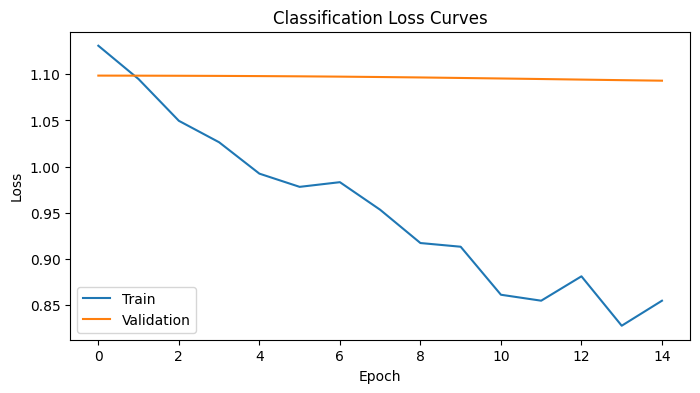

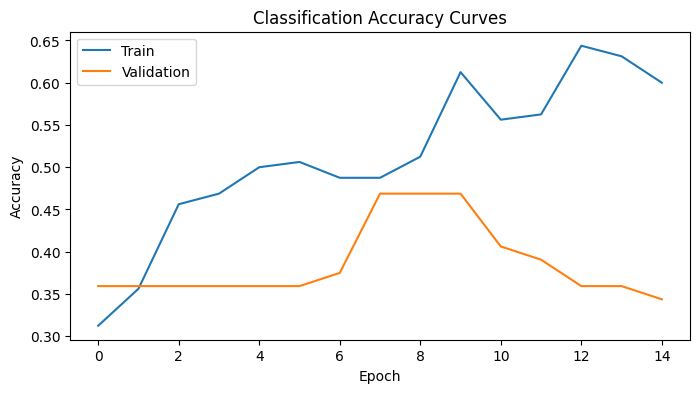

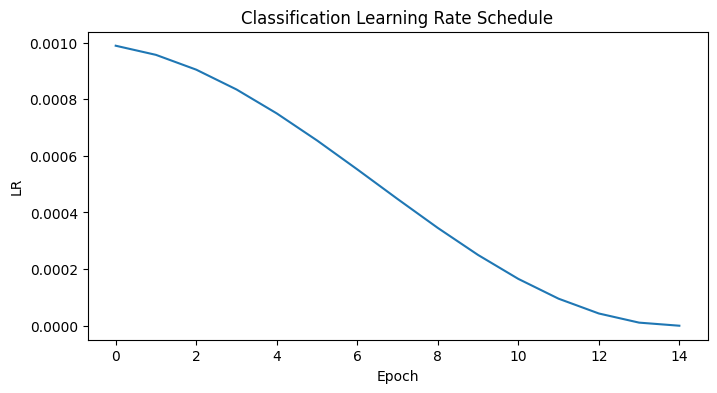

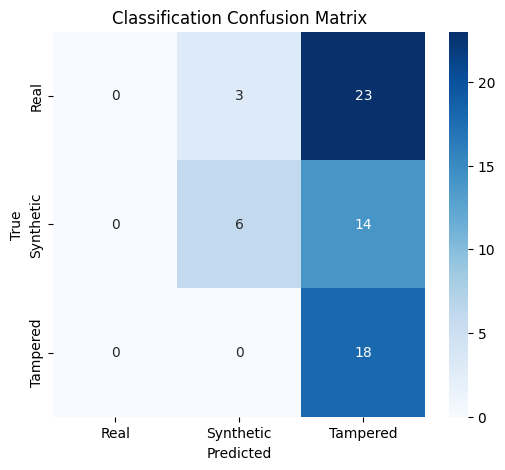

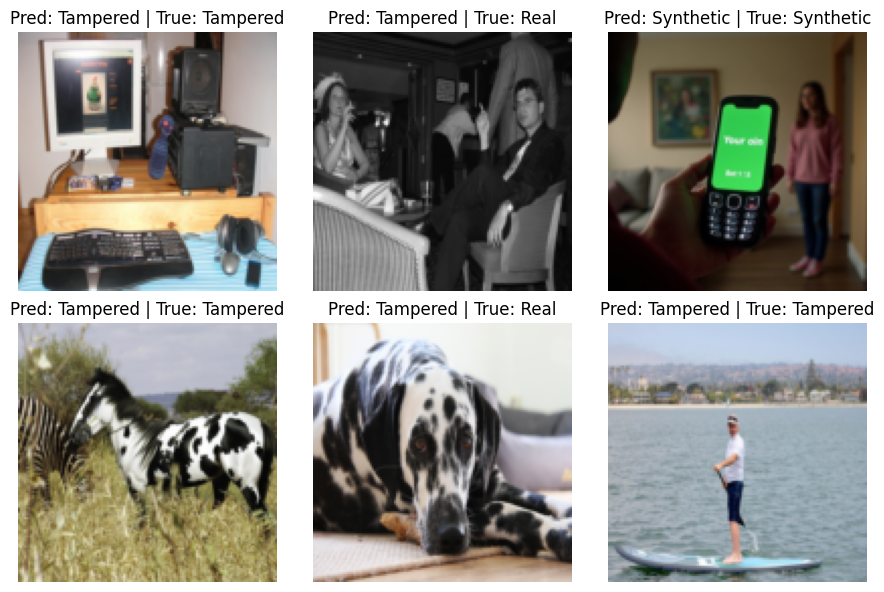

Classification artefacts:
best_model.pthevaluation.jsonhistory.json


In [10]:
# ==================================================================================================
# Evaluation Section — Metrics, Visualisations, And Artefacts
# ==================================================================================================
# Persist the best-performing EMA weights, capture the training history for reproducibility, and
# assess the classifier on the held-out test subset. Visual diagnostics complement the aggregate
# metrics so we can spot trends such as overfitting or class imbalance at a glance.
model_path_c = CLASS_RUN_DIR / 'best_model.pth'
history_path_c = CLASS_RUN_DIR / 'history.json'
torch.save(ema_c.state_dict(), model_path_c)
with history_path_c.open('w') as fp:
    json.dump({k: v for k, v in history_c.items()}, fp, indent=2)
print('Saved classification model to', model_path_c)

ema_c.eval()
all_preds: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in test_loader_c:
        images = batch['image'].to(CLASS_DEVICE)
        labels = batch['label'].to(CLASS_DEVICE)
        logits = ema_c(images)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
cm = confusion_matrix(all_labels, all_preds)
(CLASS_RUN_DIR / 'evaluation.json').write_text(
    json.dumps({'classification_report': report, 'confusion_matrix': cm.tolist()}, indent=2)
)
print('Classification macro F1:', report['macro avg']['f1-score'])

plt.figure(figsize=(8, 4))
plt.plot(history_c['train_loss'], label='Train')
plt.plot(history_c['val_loss'], label='Validation')
plt.title('Classification Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_c['train_acc'], label='Train')
plt.plot(history_c['val_acc'], label='Validation')
plt.title('Classification Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_c['lr'])
plt.title('Classification Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

sample_batch = next(iter(test_loader_c))
images = sample_batch['image'][:6].to(CLASS_DEVICE)
labels = sample_batch['label'][:6]

with torch.no_grad():
    logits = ema_c(images)
    preds = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, img, pred, label in zip(axes.flatten(), images.cpu(), preds, labels):
    img_disp = (
        img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    )
    pred_idx = int(pred.item()) if isinstance(pred, torch.Tensor) else int(pred)
    label_idx = int(label.item()) if isinstance(label, torch.Tensor) else int(label)
    ax.imshow(np.transpose(img_disp.clamp(0, 1).numpy(), (1, 2, 0)))
    ax.set_title(f"Pred: {CLASS_NAMES[pred_idx]} | True: {CLASS_NAMES[label_idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Classification artefacts:')
print(''.join(sorted(p.name for p in CLASS_RUN_DIR.iterdir())))


## Part B — Segmentation Pipeline

The second half of the project walks through a U-Net style segmentation model that highlights manipulated regions. Each subsection isolates a single responsibility so you can understand how masks are prepared, how the network is constructed, and how results are measured without jumping between cells.


### B.1 Initialization Section — Imports, Reproducibility, And Device Helpers

Segmentation keeps its dependencies self-contained so it can run independently from the classifier. We also define small utilities for deterministic execution and for selecting the most capable device available on the machine.


In [11]:
# ==================================================================================================
# Initialization Section — Imports, Reproducibility, And Device Helpers
# ==================================================================================================
# The segmentation walkthrough depends on PyTorch for tensor operations, torchvision for mask-aware
# transforms, Hugging Face Datasets for streaming SID_Set records, and matplotlib/seaborn for visual
# diagnostics. Keeping these imports together documents exactly what needs to be installed beforehand.
import json
import math
import random
from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch import amp
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset


def seg_set_seed(seed: int) -> None:
    """Reseed Python, NumPy, and PyTorch so repeated segmentation runs line up exactly."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seg_timestamp() -> str:
    """Return a UTC timestamp used for naming segmentation run folders and artefacts."""
    return datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


def seg_device() -> torch.device:
    """Prefer CUDA when it is present; otherwise continue on the CPU for universal compatibility."""
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


### B.2 Configuration Section — Experiment Hyperparameters And Run Directory

Next we collect the settings specific to segmentation. Separating these from the classifier lets us tune image size, sampling, and optimisation behaviour independently while still documenting why each default value was chosen.


In [12]:
# ==================================================================================================
# Configuration Section — Experiment Hyperparameters And Run Directory
# ==================================================================================================
# The configuration keeps the demonstration compact while covering the full segmentation workflow.
# Dataset slices remain small enough for quick iteration, the learning rate pairs well with AdamW on
# U-Net architectures, and the epoch count highlights convergence without overfitting the limited
# subset of SID_Set masks.
SEG_CFG = {
    'dataset_name': 'saberzl/SID_Set',
    'image_size': 256,
    'train_samples': 220,
    'val_samples': 80,
    'test_samples': 80,
    'batch_size': 8,
    'num_workers': 0,
    'learning_rate': 6e-4,
    'epochs': 18,
    'grad_clip_norm': 1.5,
    'ema_decay': 0.99,
    'use_cosine_schedule': True,
    'augment': True,
    'seed': 1337,
    'output_root': Path('project_outputs_segmentation'),
}

SEG_CFG['output_root'].mkdir(parents=True, exist_ok=True)
seg_set_seed(SEG_CFG['seed'])

SEG_DEVICE = seg_device()
SEG_RUN_ID = seg_timestamp()
SEG_RUN_DIR = SEG_CFG['output_root'] / SEG_RUN_ID
SEG_RUN_DIR.mkdir(parents=True, exist_ok=True)

print('Segmentation configuration:')
print(json.dumps({k: (str(v) if isinstance(v, Path) else v) for k, v in SEG_CFG.items()}, indent=2))
print('Device:', SEG_DEVICE)
print('Output folder:', SEG_RUN_DIR)


Segmentation configuration:
{
  "dataset_name": "saberzl/SID_Set",
  "image_size": 256,
  "train_samples": 220,
  "val_samples": 80,
  "test_samples": 80,
  "batch_size": 8,
  "num_workers": 0,
  "learning_rate": 0.0006,
  "epochs": 18,
  "grad_clip_norm": 1.5,
  "ema_decay": 0.99,
  "use_cosine_schedule": true,
  "augment": true,
  "seed": 1337,
  "output_root": "project_outputs_segmentation"
}
Device: cuda
Output folder: project_outputs_segmentation/20251102T134157Z


/tmp/ipykernel_79167/254566123.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


### B.3 Data Preparation Section — Augmentation And Dataset Utilities

Segmentation requires paired image and mask processing so that spatial alignment is never lost. The following subsections isolate augmentation, tensor conversion, dataset filtering, and dataset wrapping into focused helpers.


#### B.3.1 Paired Augmentation Utilities — Keep Images And Masks Synchronized

These helpers apply identical spatial transforms to both the RGB frame and its manipulation mask. Matching crops, flips, and perspective warps prevents label drift while still exposing the network to realistic variation.


In [13]:
# Paired augmentation configuration keeps the image and mask changes in lockstep.
@dataclass
class SegAugCfg:
    image_size: int
    enable: bool


def seg_random_crop_pair(image, mask, size, scale=(0.6, 1.0), ratio=(0.75, 1.33)):
    """Sample a random crop that fits both image and mask, falling back to resize if no crop fits."""
    for _ in range(10):
        area = image.width * image.height
        target_area = area * random.uniform(*scale)
        aspect_ratio = math.exp(random.uniform(math.log(ratio[0]), math.log(ratio[1])))
        new_w = int(round(math.sqrt(target_area * aspect_ratio)))
        new_h = int(round(math.sqrt(target_area / aspect_ratio)))
        if new_w <= image.width and new_h <= image.height:
            top = random.randint(0, image.height - new_h)
            left = random.randint(0, image.width - new_w)
            image = F.resized_crop(image, top, left, new_h, new_w, size)
            mask = F.resized_crop(mask, top, left, new_h, new_w, size, interpolation=F.InterpolationMode.NEAREST)
            return image, mask
    return F.resize(image, size), F.resize(mask, size, interpolation=F.InterpolationMode.NEAREST)


def seg_augment(image, mask, cfg: SegAugCfg):
    """Apply matched geometric and colour augmentations when enabled, otherwise perform a resize."""
    if not cfg.enable:
        image = F.resize(image, (cfg.image_size, cfg.image_size))
        mask = F.resize(mask, (cfg.image_size, cfg.image_size), interpolation=F.InterpolationMode.NEAREST)
        return image, mask

    image, mask = seg_random_crop_pair(image, mask, (cfg.image_size, cfg.image_size))
    if random.random() < 0.5:
        image = F.hflip(image)
        mask = F.hflip(mask)
    if random.random() < 0.3:
        pts = [(random.randint(-12, 12), random.randint(-12, 12)) for _ in range(4)]
        image = F.perspective(
            image,
            [(0, 0), (image.width - 1, 0), (image.width - 1, image.height - 1), (0, image.height - 1)],
            pts,
            interpolation=F.InterpolationMode.BILINEAR,
        )
        mask = F.perspective(
            mask,
            [(0, 0), (mask.width - 1, 0), (mask.width - 1, mask.height - 1), (0, mask.height - 1)],
            pts,
            interpolation=F.InterpolationMode.NEAREST,
        )
    image = F.adjust_brightness(image, 1.0 + random.uniform(-0.2, 0.2))
    image = F.adjust_contrast(image, 1.0 + random.uniform(-0.2, 0.2))
    image = F.adjust_saturation(image, 1.0 + random.uniform(-0.15, 0.15))
    return image, mask


#### B.3.2 Tensor Conversion Helper — Normalise Inputs And Binarise Masks

After augmentation we convert the paired PIL images into tensors. This helper applies ImageNet statistics to the RGB frame and thresholds the mask so the network learns a clean binary target.


In [14]:
def seg_to_tensor(image, mask):
    """Convert the paired PIL image and mask into normalised tensors ready for PyTorch."""
    image = F.to_tensor(image)
    image = F.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    mask = F.to_tensor(mask)
    return image, (mask > 0.5).float()


#### B.3.3 Dataset Filtering Utilities — Select Masked Tampered Frames

SID_Set mixes real, synthetic, and tampered samples. These helpers cache label indices and quickly pick only the tampered frames that include masks, avoiding repeated scans through the full dataset on every run.


In [15]:
_SEG_LABEL_CACHE: dict[tuple[str, int], list[int]] = {}


def seg_label_indices(hf_dataset, label_value: int) -> list[int]:
    """Cache indices for samples matching the requested label to minimise repeated filtering work."""
    fingerprint = getattr(hf_dataset, '_fingerprint', None)
    cache_key = (str(fingerprint), label_value)
    if cache_key not in _SEG_LABEL_CACHE:
        labels = hf_dataset['label']
        _SEG_LABEL_CACHE[cache_key] = [idx for idx, lbl in enumerate(labels) if lbl == label_value]
    return _SEG_LABEL_CACHE[cache_key]


def seg_filter(hf_dataset, max_samples):
    """Select tampered frames that provide masks, warning if fewer samples are available than requested."""
    candidate_indices = seg_label_indices(hf_dataset, label_value=2)
    picked_indices: list[int] = []
    for idx in candidate_indices:
        record = hf_dataset[idx]
        if record['mask'] is None:
            continue
        picked_indices.append(idx)
        if max_samples is not None and len(picked_indices) >= max_samples:
            break
    if max_samples is not None and len(picked_indices) < max_samples:
        print(f"[seg_filter] Requested {max_samples} samples but only found {len(picked_indices)} with masks.")
    return hf_dataset.select(picked_indices)


#### B.3.4 Dataset Wrapper — Emit Image And Mask Tensors

The dataset wrapper ties everything together by applying augmentation, tensor conversion, and returning dictionary-based samples. This keeps the training loop concise and self-explanatory.


In [16]:
class SegDataset(Dataset):
    """Return paired image and mask tensors from the filtered Hugging Face dataset."""

    def __init__(self, hf_dataset, image_size, augment=False):
        self.dataset = hf_dataset
        self.cfg = SegAugCfg(image_size=image_size, enable=augment)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        record = self.dataset[idx]
        image = record['image'].convert('RGB')
        mask = record['mask']
        if mask.mode != 'L':
            mask = mask.convert('L')
        image, mask = seg_augment(image, mask, self.cfg)
        image, mask = seg_to_tensor(image, mask)
        return {'image': image, 'mask': mask}


### B.4 Data Loader Section — Dataset Construction And Visual Sanity Check

With the building blocks defined, we assemble deterministic dataset splits and inspect a mini-batch. This verifies that augmentation kept the masks aligned and that the loaders respect the configured batch size.


#### B.4.1 Instantiate Dataset Splits And Loaders

We filter tampered frames into train, validation, and test subsets, wrap them in SegDataset instances, and construct DataLoaders that handle batching and shuffling.


In [17]:
train_raw = seg_filter(load_dataset(SEG_CFG['dataset_name'], split='train', streaming=False), SEG_CFG['train_samples'])
val_raw_full = seg_filter(load_dataset(SEG_CFG['dataset_name'], split='validation', streaming=False), SEG_CFG['val_samples'] + SEG_CFG['test_samples'])
val_raw = val_raw_full.select(range(SEG_CFG['val_samples']))
test_raw = val_raw_full.select(range(SEG_CFG['val_samples'], SEG_CFG['val_samples'] + SEG_CFG['test_samples']))

train_ds_seg = SegDataset(train_raw, SEG_CFG['image_size'], augment=SEG_CFG['augment'])
val_ds_seg = SegDataset(val_raw, SEG_CFG['image_size'], augment=False)
test_ds_seg = SegDataset(test_raw, SEG_CFG['image_size'], augment=False)

train_loader_seg = DataLoader(train_ds_seg, batch_size=SEG_CFG['batch_size'], shuffle=True, num_workers=SEG_CFG['num_workers'])
val_loader_seg = DataLoader(val_ds_seg, batch_size=SEG_CFG['batch_size'], shuffle=False, num_workers=SEG_CFG['num_workers'])
test_loader_seg = DataLoader(test_ds_seg, batch_size=SEG_CFG['batch_size'], shuffle=False, num_workers=SEG_CFG['num_workers'])

print('Segmentation dataset sizes -> train:', len(train_raw), 'val:', len(val_raw), 'test:', len(test_raw))
print('Segmentation dataloaders -> train:', len(train_loader_seg), 'val:', len(val_loader_seg), 'test:', len(test_loader_seg))


Segmentation dataset sizes -> train: 220 val: 80 test: 80
Segmentation dataloaders -> train: 28 val: 10 test: 10


#### B.4.2 Preview Augmented Samples And Masks

Plotting a few training pairs helps confirm that the augmentations remain realistic and that masks stay aligned with their corresponding images.


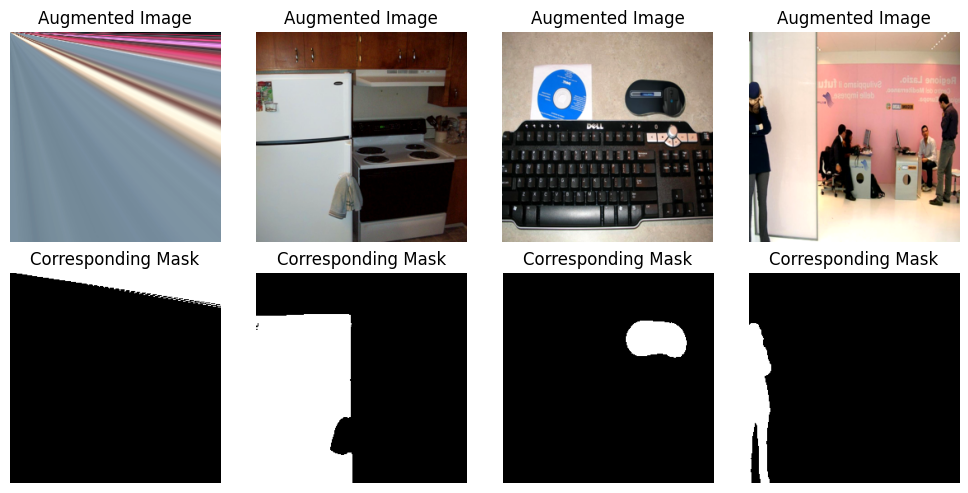

In [18]:
preview_batch = next(iter(train_loader_seg))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    img = preview_batch['image'][i]
    mask = preview_batch['mask'][i]
    img_disp = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    axes[0, i].imshow(np.transpose(img_disp.clamp(0, 1).numpy(), (1, 2, 0)))
    axes[0, i].set_title('Augmented Image')
    axes[0, i].axis('off')
    axes[1, i].imshow(mask.squeeze(0).numpy(), cmap='gray')
    axes[1, i].set_title('Corresponding Mask')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


### B.5 Model And Optimisation Section — Architecture, Losses, And Training Tools

The segmentation model relies on a compact U-Net. We separate the architectural definition, the loss and metric utilities, and the optimisation objects so each component can be reasoned about independently.


#### B.5.1 U-Net Architecture Definition

This variant of U-Net balances capacity and speed. Encoder and decoder blocks share a common Conv-BN-ReLU pattern, while transpose convolutions handle upsampling before skip connections merge encoder features.


In [19]:
class SegConvBlock(nn.Module):
    """Two Conv-BatchNorm-ReLU layers reused throughout the encoder and decoder."""

    def __init__(self, in_channels: int, out_channels: int, *, use_batchnorm: bool = True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels) if use_batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNet(nn.Module):
    """A streamlined U-Net with skip connections to recover spatial detail in the prediction."""

    def __init__(self, base_width: int = 32):
        super().__init__()
        b = base_width
        self.enc1 = SegConvBlock(3, b)
        self.enc2 = SegConvBlock(b, b * 2)
        self.enc3 = SegConvBlock(b * 2, b * 4)
        self.enc4 = SegConvBlock(b * 4, b * 8)
        self.pool = nn.MaxPool2d(2)
        self.center = SegConvBlock(b * 8, b * 16)
        self.up4 = nn.ConvTranspose2d(b * 16, b * 8, kernel_size=2, stride=2)
        self.dec4 = SegConvBlock(b * 16, b * 8)
        self.up3 = nn.ConvTranspose2d(b * 8, b * 4, kernel_size=2, stride=2)
        self.dec3 = SegConvBlock(b * 8, b * 4)
        self.up2 = nn.ConvTranspose2d(b * 4, b * 2, kernel_size=2, stride=2)
        self.dec2 = SegConvBlock(b * 4, b * 2)
        self.up1 = nn.ConvTranspose2d(b * 2, b, kernel_size=2, stride=2)
        self.dec1 = SegConvBlock(b * 2, b)
        self.head = nn.Conv2d(b, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        center = self.center(self.pool(enc4))
        dec4 = self.dec4(torch.cat([self.up4(center), enc4], dim=1))
        dec3 = self.dec3(torch.cat([self.up3(dec4), enc3], dim=1))
        dec2 = self.dec2(torch.cat([self.up2(dec3), enc2], dim=1))
        dec1 = self.dec1(torch.cat([self.up1(dec2), enc1], dim=1))
        return self.head(dec1)


#### B.5.2 Loss And Metric Utilities

Dice and IoU emphasise spatial overlap, which is critical for segmentation. We keep these helpers close to the model definition so they can be inspected or swapped without hunting through the notebook.


In [20]:
def dice_loss(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Compute the soft Dice loss, encouraging overlap between predictions and ground-truth masks."""
    probs = torch.sigmoid(logits)
    num = (probs * targets).sum(dim=(1, 2, 3))
    den = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return 1 - (2 * num + eps) / (den + eps)


def dice_coefficient(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Measure the Dice score after thresholding logits into binary masks."""
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    num = (preds * targets).sum(dim=(1, 2, 3))
    den = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return (2 * num + eps) / (den + eps)


def iou_coefficient(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Compute the Intersection over Union, a complementary view of segmentation quality."""
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    return (intersection + eps) / (union + eps)


#### B.5.3 Optimisation Setup — Loss Function, Optimiser, Scheduler, EMA

Finally we wire up the loss, optimiser, learning rate schedule, and EMA clone. Keeping these in one place clarifies how gradients flow and how the best-performing weights are tracked.


In [21]:
model_seg = UNet(base_width=32).to(SEG_DEVICE)
criterion_bce_seg = nn.BCEWithLogitsLoss()
optimizer_seg = optim.AdamW(model_seg.parameters(), lr=SEG_CFG['learning_rate'], weight_decay=1e-4)
scaler_seg = amp.GradScaler(enabled=(SEG_DEVICE.type == 'cuda'))
scheduler_seg = (
    optim.lr_scheduler.CosineAnnealingLR(optimizer_seg, T_max=SEG_CFG['epochs'])
    if SEG_CFG['use_cosine_schedule']
    else None
)
ema_seg = UNet(base_width=32).to(SEG_DEVICE)
ema_seg.load_state_dict(model_seg.state_dict())
for param in ema_seg.parameters():
    param.requires_grad_(False)


### B.6 Training Loop Section — Dice-Focused Optimisation

The training routine balances binary cross-entropy with soft Dice loss, updates an EMA snapshot, and records Dice and IoU metrics. Validation always runs against the EMA copy to reflect the weights we plan to export.


In [22]:
# ==================================================================================================
# Training Loop Section — Dice-Focused Optimisation
# ==================================================================================================
# The segmentation loop mirrors the classifier structure but tracks overlap-centric metrics. Gradient
# clipping guards against destabilising updates, and the EMA clone smooths validation performance.
history_seg = defaultdict(list)
best_state_seg = None
best_val_dice = -math.inf

for epoch in range(SEG_CFG['epochs']):
    model_seg.train()
    train_loss = 0.0
    train_dice = 0.0
    batches = 0

    for batch in train_loader_seg:
        images = batch['image'].to(SEG_DEVICE)
        masks = batch['mask'].to(SEG_DEVICE)

        optimizer_seg.zero_grad(set_to_none=True)
        with amp.autocast(device_type='cuda', enabled=(SEG_DEVICE.type == 'cuda')):
            logits = model_seg(images)
            bce = criterion_bce_seg(logits, masks)
            dice = dice_loss(logits, masks).mean()
            loss = 0.5 * bce + 0.5 * dice

        scaler_seg.scale(loss).backward()
        if SEG_CFG['grad_clip_norm'] > 0:
            scaler_seg.unscale_(optimizer_seg)
            torch.nn.utils.clip_grad_norm_(model_seg.parameters(), SEG_CFG['grad_clip_norm'])
        scaler_seg.step(optimizer_seg)
        scaler_seg.update()

        if SEG_CFG['ema_decay'] > 0:
            for ema_param, param in zip(ema_seg.parameters(), model_seg.parameters()):
                ema_param.data.mul_(SEG_CFG['ema_decay']).add_(param.data, alpha=1 - SEG_CFG['ema_decay'])

        train_loss += loss.item()
        train_dice += dice_coefficient(logits, masks).mean().item()
        batches += 1

    if scheduler_seg is not None:
        scheduler_seg.step()

    model_seg.eval()
    ema_seg.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    val_batches = 0
    with torch.no_grad():
        for batch in val_loader_seg:
            images = batch['image'].to(SEG_DEVICE)
            masks = batch['mask'].to(SEG_DEVICE)
            logits = ema_seg(images)
            bce = criterion_bce_seg(logits, masks)
            dice = dice_loss(logits, masks).mean()
            loss = 0.5 * bce + 0.5 * dice
            val_loss += loss.item()
            val_dice += dice_coefficient(logits, masks).mean().item()
            val_iou += iou_coefficient(logits, masks).mean().item()
            val_batches += 1

    train_loss /= max(batches, 1)
    train_dice /= max(batches, 1)
    val_loss /= max(val_batches, 1)
    val_dice /= max(val_batches, 1)
    val_iou /= max(val_batches, 1)

    history_seg['train_loss'].append(train_loss)
    history_seg['train_dice'].append(train_dice)
    history_seg['val_loss'].append(val_loss)
    history_seg['val_dice'].append(val_dice)
    history_seg['val_iou'].append(val_iou)
    history_seg['lr'].append(optimizer_seg.param_groups[0]['lr'])

    print(
        f"[Segmentation] Epoch {epoch + 1:02d}/{SEG_CFG['epochs']} "
        f"train_loss={train_loss:.3f} train_dice={train_dice:.3f} "
        f"val_loss={val_loss:.3f} val_dice={val_dice:.3f} val_iou={val_iou:.3f}"
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_state_seg = {k: v.clone() for k, v in ema_seg.state_dict().items()}

if best_state_seg is not None:
    ema_seg.load_state_dict(best_state_seg)


[Segmentation] Epoch 01/18 train_loss=0.696 train_dice=0.170 val_loss=0.733 val_dice=0.000 val_iou=0.000
[Segmentation] Epoch 02/18 train_loss=0.660 train_dice=0.217 val_loss=0.730 val_dice=0.000 val_iou=0.000
[Segmentation] Epoch 03/18 train_loss=0.646 train_dice=0.127 val_loss=0.727 val_dice=0.000 val_iou=0.000
[Segmentation] Epoch 04/18 train_loss=0.637 train_dice=0.160 val_loss=0.754 val_dice=0.275 val_iou=0.185
[Segmentation] Epoch 05/18 train_loss=0.637 train_dice=0.213 val_loss=1.786 val_dice=0.244 val_iou=0.164
[Segmentation] Epoch 06/18 train_loss=0.626 train_dice=0.211 val_loss=17.331 val_dice=0.242 val_iou=0.163
[Segmentation] Epoch 07/18 train_loss=0.631 train_dice=0.249 val_loss=130.122 val_dice=0.242 val_iou=0.162
[Segmentation] Epoch 08/18 train_loss=0.623 train_dice=0.249 val_loss=976.883 val_dice=0.241 val_iou=0.162
[Segmentation] Epoch 09/18 train_loss=0.620 train_dice=0.259 val_loss=5106.584 val_dice=0.241 val_iou=0.162
[Segmentation] Epoch 10/18 train_loss=0.615 tra

### B.7 Evaluation Section — Metrics, Visualisations, And Artefacts

Finally we freeze the EMA weights, compute Dice and IoU on the test split, render convergence plots, and display qualitative predictions to connect the numbers back to actual frames.


Saved segmentation model to project_outputs_segmentation/20251102T134157Z/best_model.pth
Segmentation dice 0.264 ± 0.205
Segmentation IoU  0.170 ± 0.155


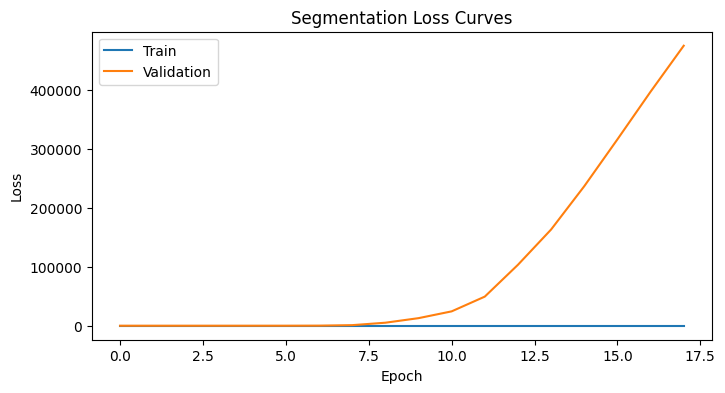

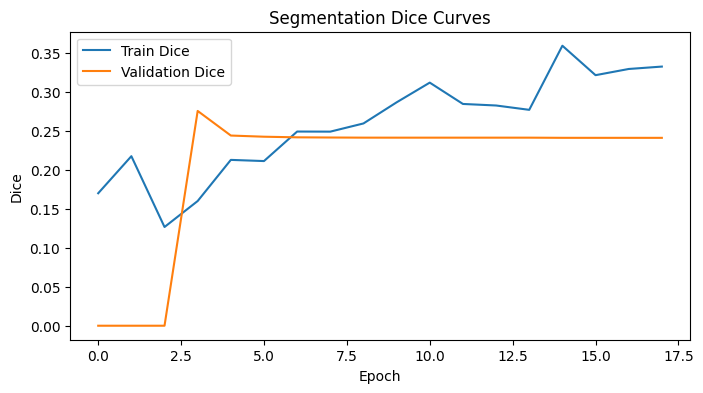

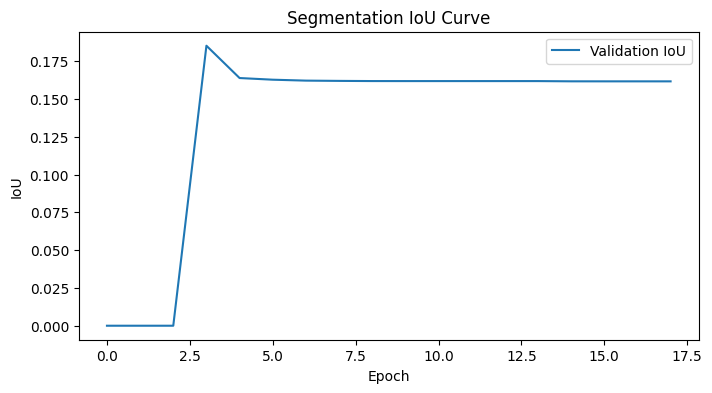

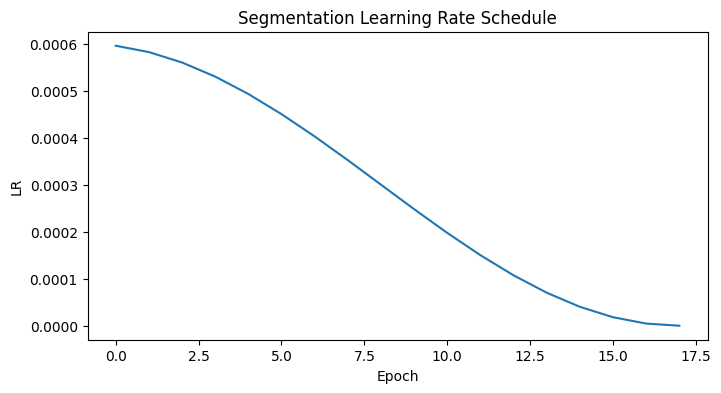

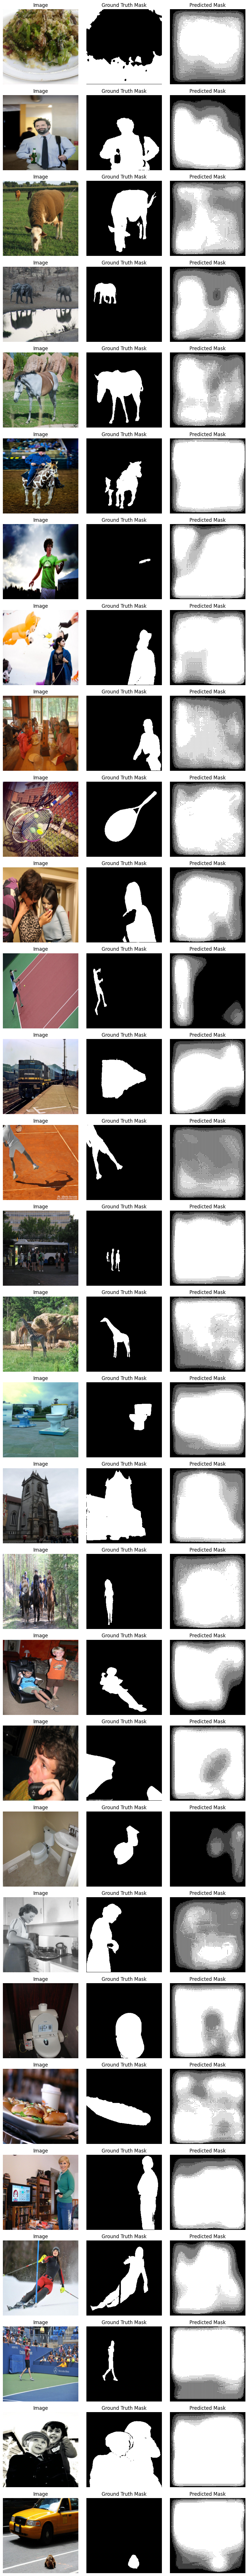

Segmentation artefacts:
best_model.pthevaluation.jsonhistory.json


In [23]:
# ==================================================================================================
# Evaluation Section — Metrics, Visualisations, And Artefacts
# ==================================================================================================
# Saving the weights and metrics makes the run reproducible, while plots and sample outputs reveal how
# well the model localises manipulated regions beyond raw numbers.
model_path_seg = SEG_RUN_DIR / 'best_model.pth'
history_path_seg = SEG_RUN_DIR / 'history.json'
torch.save(ema_seg.state_dict(), model_path_seg)
with history_path_seg.open('w') as fp:
    json.dump({k: v for k, v in history_seg.items()}, fp, indent=2)
print('Saved segmentation model to', model_path_seg)

segmentation_dice_scores: list[float] = []
segmentation_iou_scores: list[float] = []
qualitative_examples: list[tuple[torch.Tensor, torch.Tensor, torch.Tensor]] = []
ema_seg.eval()
with torch.no_grad():
    for batch in test_loader_seg:
        images = batch['image'].to(SEG_DEVICE)
        masks = batch['mask'].to(SEG_DEVICE)
        logits = ema_seg(images)
        segmentation_dice_scores.extend(dice_coefficient(logits, masks).cpu().tolist())
        segmentation_iou_scores.extend(iou_coefficient(logits, masks).cpu().tolist())
        preds = (torch.sigmoid(logits) > 0.5).float()
        for img, mask, pred in zip(images[:3], masks[:3], preds[:3]):
            qualitative_examples.append((img.cpu(), mask.cpu(), pred.cpu()))

(SEG_RUN_DIR / 'evaluation.json').write_text(
    json.dumps(
        {
            'dice_scores': segmentation_dice_scores,
            'iou_scores': segmentation_iou_scores,
        },
        indent=2,
    )
)
print(f"Segmentation dice {np.mean(segmentation_dice_scores):.3f} ± {np.std(segmentation_dice_scores):.3f}")
print(f"Segmentation IoU  {np.mean(segmentation_iou_scores):.3f} ± {np.std(segmentation_iou_scores):.3f}")

plt.figure(figsize=(8, 4))
plt.plot(history_seg['train_loss'], label='Train')
plt.plot(history_seg['val_loss'], label='Validation')
plt.title('Segmentation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_seg['train_dice'], label='Train Dice')
plt.plot(history_seg['val_dice'], label='Validation Dice')
plt.title('Segmentation Dice Curves')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_seg['val_iou'], label='Validation IoU')
plt.title('Segmentation IoU Curve')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_seg['lr'])
plt.title('Segmentation Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.show()

rows = len(qualitative_examples)
fig, axes = plt.subplots(rows, 3, figsize=(9, 3 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)
for row, (img, mask, pred) in enumerate(qualitative_examples):
    img_disp = (
        img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    )
    axes[row, 0].imshow(np.transpose(img_disp.clamp(0, 1).numpy(), (1, 2, 0)))
    axes[row, 0].set_title('Image')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(mask.squeeze(0).numpy(), cmap='gray')
    axes[row, 1].set_title('Ground Truth Mask')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(pred.squeeze(0).numpy(), cmap='gray')
    axes[row, 2].set_title('Predicted Mask')
    axes[row, 2].axis('off')
plt.tight_layout()
plt.show()

print('Segmentation artefacts:')
print(''.join(sorted(p.name for p in SEG_RUN_DIR.iterdir())))
